In [1]:
# Install required deps for YOLOv8 + HF Hub (safe to re-run)
%pip install -U ultralytics huggingface_hub pillow


Requirement already up-to-date: ultralytics in /usr/local/lib/python3.8/dist-packages (8.3.232)
Requirement already up-to-date: huggingface_hub in /usr/local/lib/python3.8/dist-packages (0.36.0)
Requirement already up-to-date: pillow in /usr/local/lib/python3.8/dist-packages (10.4.0)
Note: you may need to restart the kernel to use updated packages.


## Load model
I looked on huggingface: I did find a model there that used chess pieces: https://huggingface.co/NAKSTStudio/yolov8m-chess-piece-detection, it is not specific for chess.com.



In [2]:
# Load YOLOv8 chess piece detector from Hugging Face
from ultralytics import YOLO
try:
    # Ultralytics can load directly from the Hub using the repo id
    model = YOLO("NAKSTStudio/yolov8m-chess-piece-detection")
except Exception as e:
    # Fallback: download the weights explicitly, then load
    from huggingface_hub import hf_hub_download
    weights_path = hf_hub_download(repo_id="NAKSTStudio/yolov8m-chess-piece-detection", filename="best.pt")
    model = YOLO(weights_path)
print("Loaded model:", model)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, 

## Model and Dataset Analysis

Since we're using an existing pre-trained model, we don't know the dataset. The model is based on YOLOv8, so that should be fast enough for our application. Both the white pieces, black pieces and the board are detected.


In [ ]:
# Model information
print("\n1. MODEL ARCHITECTURE:")
print(f"   Model Type: {type(model).__name__}")
print(f"   Model Name: YOLOv8 Medium (yolov8m)")

# Get class names from the model
class_names = model.names
num_classes = len(class_names)

print(f"\n2. CLASS INFORMATION:")
print(f"   Total classes: {num_classes}")
print(f"\n   Class list:")
for class_id, class_name in sorted(class_names.items()):
    print(f"      ID {class_id:2d}: {class_name}")


1. MODEL ARCHITECTURE:
   Model Type: YOLO
   Model Name: YOLOv8 Medium (yolov8m)

2. CLASS INFORMATION:
   Total classes: 13

   Class list:
      ID  0: board
      ID  1: white_king
      ID  2: white_queen
      ID  3: white_rook
      ID  4: white_bishop
      ID  5: white_knight
      ID  6: white_pawn
      ID  7: black_king
      ID  8: black_queen
      ID  9: black_rook
      ID 10: black_bishop
      ID 11: black_knight
      ID 12: black_pawn


# Visual validation of the selected model
Take some images from our test set and visualize the object detection.
On the default images of chess.com, the results are very reliable. Chess.com also has runescape themed chesspieces, those have more mistakes in them, especially for the bishops, queen and king.


image 1/1 /workspace/data/chessboards/chrome_164320_as_cropped.png: 832x832 1 board, 1 white_king, 2 white_rooks, 1 white_bishop, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 6 black_pawns, 43.4ms
Speed: 3.8ms preprocess, 43.4ms inference, 24.0ms postprocess per image at shape (1, 3, 832, 832)


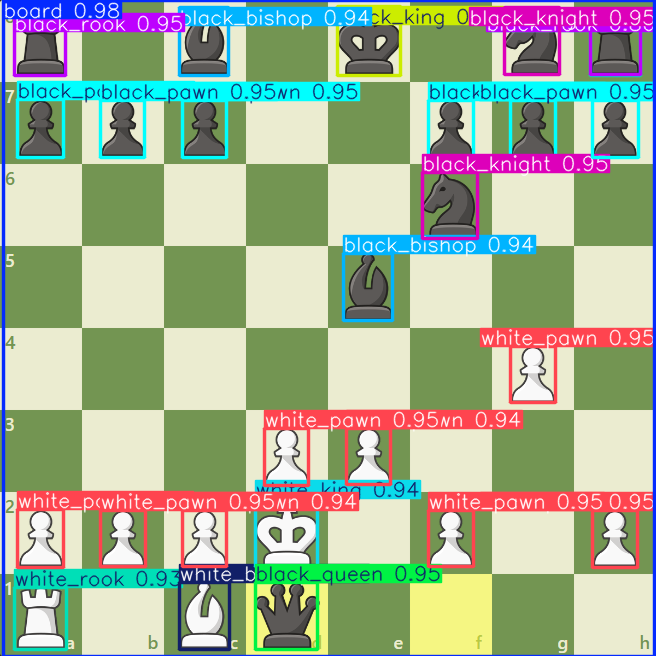

In [11]:
img_path = "data/chessboards/chrome_164320_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 /workspace/data/chessboards/chrome_164950_as_cropped.png: 832x832 1 board, 4 white_queens, 2 white_rooks, 2 white_knights, 7 white_pawns, 1 black_king, 2 black_queens, 2 black_rooks, 1 black_knight, 6 black_pawns, 341.5ms
Speed: 5.7ms preprocess, 341.5ms inference, 20.2ms postprocess per image at shape (1, 3, 832, 832)


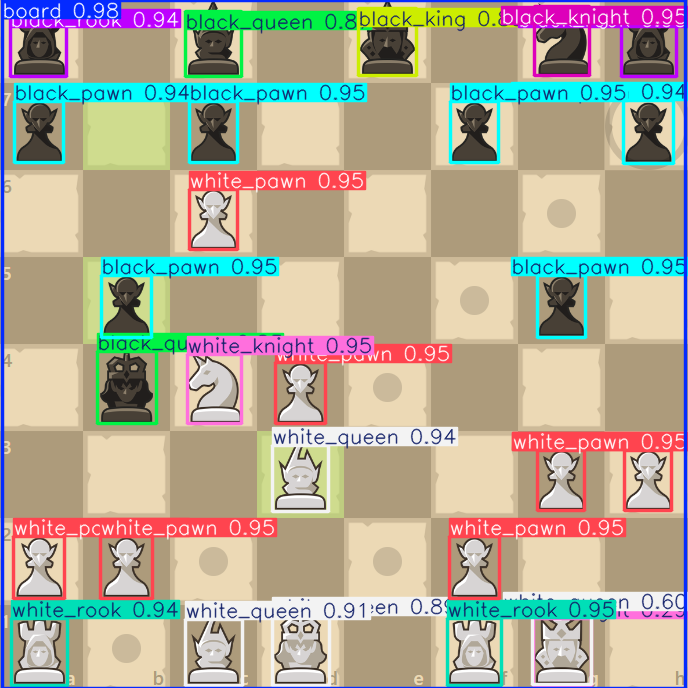

In [12]:
img_path = "data/chessboards/chrome_164950_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

## COCO Model Evaluation

Let's evaluate the models on the COCO test dataset to get proper metrics (mAP, precision, recall). 

### Test dataset creation

Use the existing model to auto-annotate unannotated images, then export them for correction in CVAT.

**Workflow:**
1. Run inference on unannotated images using the NAKTSTUDIO model
2. Export predictions in COCO format (CVAT-compatible)
3. Import into CVAT for review and correction
4. Export corrected annotations from CVAT
5. Use corrected annotations for further training

In [ ]:
# Auto-annotate unannotated images and export in COCO format for CVAT
import json
from pathlib import Path
from PIL import Image
from datetime import datetime
from tqdm import tqdm

def yolo_to_coco_bbox(x_center, y_center, width, height, img_width, img_height):
    """Convert YOLO format to COCO format (x, y, width, height where x,y is top-left)."""
    abs_x_center = x_center * img_width
    abs_y_center = y_center * img_height
    abs_width = width * img_width
    abs_height = height * img_height
    
    x = max(0, abs_x_center - abs_width / 2)
    y = max(0, abs_y_center - abs_height / 2)
    abs_width = min(abs_width, img_width - x)
    abs_height = min(abs_height, img_height - y)
    
    return [round(x, 2), round(y, 2), round(abs_width, 2), round(abs_height, 2)]

def create_coco_categories(model):
    """Create COCO categories from model class names."""
    categories = [{"id": 0, "name": "Chess-pieces", "supercategory": "none"}]
    class_names = model.names
    
    for class_id, class_name in sorted(class_names.items()):
        categories.append({
            "id": class_id + 1,
            "name": class_name,
            "supercategory": "Chess-pieces" if class_name != "board" else "none"
        })
    
    return categories

def auto_annotate_for_cvat(model, input_dir, output_dir, conf_threshold=0.25):
    """
    Auto-annotate images and export in COCO format for CVAT import.
    
    Args:
        model: YOLOv8 model
        input_dir: Directory with unannotated images
        output_dir: Output directory for annotations
        conf_threshold: Confidence threshold for detections
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Find image files
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    image_files = [f for f in input_dir.iterdir() if f.suffix.lower() in image_extensions]
    
    if len(image_files) == 0:
        print(f"No images found in {input_dir}")
        return
    
    print(f"Found {len(image_files)} images to annotate")
    
    # Create COCO structure
    coco_data = {
        "info": {
            "year": datetime.now().year,
            "version": "1.0",
            "description": "Auto-annotated using YOLOv8",
            "contributor": "Auto-annotation",
            "date_created": datetime.now().isoformat()
        },
        "licenses": [{"id": 1, "url": "https://creativecommons.org/licenses/by/4.0/", "name": "CC BY 4.0"}],
        "categories": create_coco_categories(model),
        "images": [],
        "annotations": []
    }
    
    # Process images
    annotation_id = 1
    import shutil
    
    print("\nProcessing images...")
    for image_path in tqdm(image_files):
        image_id = len(coco_data["images"]) + 1
        
        # Get image info
        img = Image.open(image_path)
        width, height = img.size
        coco_data["images"].append({
            "id": image_id,
            "file_name": image_path.name,
            "width": width,
            "height": height,
            "license": 1,
            "date_captured": datetime.now().isoformat()
        })
        
        # Run inference
        results = model.predict(str(image_path), conf=conf_threshold, verbose=False)
        
        if results and len(results) > 0:
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                for i in range(len(boxes)):
                    cls_id = int(boxes.cls[i].cpu().numpy())
                    box_xywhn = boxes.xywhn[i].cpu().numpy()
                    x_center, y_center, width_norm, height_norm = box_xywhn
                    
                    bbox_coco = yolo_to_coco_bbox(x_center, y_center, width_norm, height_norm, width, height)
                    area = bbox_coco[2] * bbox_coco[3]
                    
                    coco_data["annotations"].append({
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": cls_id + 1,
                        "segmentation": [],
                        "area": round(area, 2),
                        "bbox": bbox_coco,
                        "iscrowd": 0
                    })
                    annotation_id += 1
        
        # Copy image to output
        shutil.copy2(image_path, output_dir / image_path.name)
    
    # Save COCO JSON
    output_json = output_dir / "auto_annotations.coco.json"
    with open(output_json, 'w') as f:
        json.dump(coco_data, f, indent=2)
    
    print(f"\n✓ Annotation complete!")
    print(f"  Images: {len(coco_data['images'])}")
    print(f"  Annotations: {len(coco_data['annotations'])}")
    print(f"  Output: {output_dir}")
    print(f"  COCO JSON: {output_json}")
    print(f"\n📋 Next steps:")
    print(f"  1. Import '{output_json.name}' into CVAT")
    print(f"  2. Review and correct annotations in CVAT")
    print(f"  3. Export corrected annotations from CVAT")
    print(f"  4. Use for training!")

auto_annotate_for_cvat(
    model=model,
    input_dir="data/browserscreenshots",
    output_dir="data/auto_annotated_browserscreenshots",
    conf_threshold=0.25
)

### Dataset evaluation

In [4]:
# Detailed Evaluation with IoU, Precision, Recall, and mAP
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from pathlib import Path
import json

def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) of two bounding boxes.
    
    Args:
        box1: [x1, y1, x2, y2] (top-left and bottom-right corners)
        box2: [x1, y1, x2, y2]
    
    Returns:
        IoU value between 0 and 1
    """
    # Calculate intersection area
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    
    # Calculate union area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

def coco_bbox_to_xyxy(bbox):
    """Convert COCO bbox [x, y, width, height] to [x1, y1, x2, y2]."""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

def match_predictions_to_ground_truth(pred_boxes, pred_classes, pred_scores, 
                                      gt_boxes, gt_classes, iou_threshold=0.5):
    """
    Match predictions to ground truth using IoU and class matching.
    
    Returns:
        tp: true positives count
        fp: false positives count
        fn: false negatives count
        matched_pairs: list of (pred_idx, gt_idx) pairs
    """
    tp = 0
    fp = 0
    matched_gt = set()
    matched_pairs = []
    
    # Sort predictions by confidence (descending)
    pred_indices = sorted(range(len(pred_boxes)), key=lambda i: pred_scores[i], reverse=True)
    
    for pred_idx in pred_indices:
        pred_box = pred_boxes[pred_idx]
        pred_class = pred_classes[pred_idx]
        best_iou = 0
        best_gt_idx = None
        
        # Find best matching ground truth box
        for gt_idx, (gt_box, gt_class) in enumerate(zip(gt_boxes, gt_classes)):
            if gt_idx in matched_gt:
                continue
            
            # Must match class
            if pred_class != gt_class:
                continue
            
            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        # Match if IoU > threshold
        if best_iou >= iou_threshold and best_gt_idx is not None:
            tp += 1
            matched_gt.add(best_gt_idx)
            matched_pairs.append((pred_idx, best_gt_idx))
        else:
            fp += 1
    
    # False negatives = unmatched ground truth
    fn = len(gt_boxes) - len(matched_gt)
    
    return tp, fp, fn, matched_pairs

def evaluate_model_on_coco(model, coco_data, image_id_to_path, 
                           conf_threshold=0.25, iou_threshold=0.5, 
                           max_images=None, verbose=True):
    """
    Evaluate a YOLOv8 model on a COCO format dataset.
    
    Args:
        model: YOLOv8 model instance
        coco_data: COCO format dictionary with 'images', 'annotations', 'categories'
        image_id_to_path: Dictionary mapping image IDs to image file paths
        conf_threshold: Confidence threshold for predictions (default: 0.25)
        iou_threshold: IoU threshold for matching predictions to ground truth (default: 0.5)
        max_images: Maximum number of images to evaluate (None = all)
        verbose: Whether to print progress and results (default: True)
    
    Returns:
        Dictionary with evaluation metrics:
        {
            'precision': float,
            'recall': float,
            'f1': float,
            'map': float,
            'tp': int,
            'fp': int,
            'fn': int,
            'class_metrics': dict  # Per-class metrics
        }
    """
    # Per-class statistics
    class_stats = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    # Get model class names and create mapping
    model_class_names = model.names
    model_name_to_id = {name: class_id for class_id, name in model_class_names.items()}
    
    # Create COCO category to model class ID mapping
    coco_to_model_class = {}
    for coco_cat in coco_data['categories']:
        coco_name = coco_cat['name']
        coco_id = coco_cat['id']
        if coco_name in model_name_to_id:
            coco_to_model_class[coco_id] = model_name_to_id[coco_name]
        else:
            # Try case-insensitive match
            coco_lower = coco_name.lower()
            for model_name, model_id in model_name_to_id.items():
                if model_name.lower() == coco_lower:
                    coco_to_model_class[coco_id] = model_id
                    break
    
    # Get image IDs to evaluate
    image_ids = list(image_id_to_path.keys())
    if max_images is not None:
        image_ids = image_ids[:max_images]
    
    if verbose:
        print(f"Evaluating on {len(image_ids)} images with IoU threshold = {iou_threshold}")
    
    # Evaluate each image
    for img_id in tqdm(image_ids, desc="  Processing", disable=not verbose):
        img_path = image_id_to_path[img_id]
        
        # Get ground truth annotations
        gt_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]
        
        # Get image dimensions
        img_info = next((img for img in coco_data['images'] if img['id'] == img_id), None)
        if img_info is None:
            continue
        
        img_width = img_info['width']
        img_height = img_info['height']
        
        # Convert GT to boxes and classes
        gt_boxes = []
        gt_classes = []
        for ann in gt_annotations:
            bbox_coco = ann['bbox']  # [x, y, width, height]
            bbox_xyxy = coco_bbox_to_xyxy(bbox_coco)
            gt_boxes.append(bbox_xyxy)
            
            # Map COCO category to model class
            coco_cat_id = ann['category_id']
            if coco_cat_id in coco_to_model_class:
                gt_classes.append(coco_to_model_class[coco_cat_id])
            else:
                gt_classes.append(None)  # Skip if can't map
        
        # Filter out None classes
        valid_gt = [(box, cls) for box, cls in zip(gt_boxes, gt_classes) if cls is not None]
        if not valid_gt:
            continue
        gt_boxes, gt_classes = zip(*valid_gt)
        gt_boxes = list(gt_boxes)
        gt_classes = list(gt_classes)
        
        # Run model prediction
        try:
            pred_results = model.predict(img_path, conf=conf_threshold, verbose=False)
            if not pred_results or len(pred_results) == 0:
                # No predictions = all false negatives
                for cls in gt_classes:
                    class_stats[cls]['fn'] += 1
                total_fn += len(gt_classes)
                continue
            
            boxes = pred_results[0].boxes
            if boxes is None or len(boxes) == 0:
                # No predictions = all false negatives
                for cls in gt_classes:
                    class_stats[cls]['fn'] += 1
                total_fn += len(gt_classes)
                continue
            
            # Convert predictions to boxes and classes
            pred_boxes = []
            pred_classes = []
            pred_scores = []
            
            for i in range(len(boxes)):
                box_xyxy = boxes.xyxy[i].cpu().numpy().tolist()
                cls_id = int(boxes.cls[i].cpu().numpy())
                score = float(boxes.conf[i].cpu().numpy())
                
                pred_boxes.append(box_xyxy)
                pred_classes.append(cls_id)
                pred_scores.append(score)
            
            # Match predictions to ground truth
            tp, fp, fn, matched = match_predictions_to_ground_truth(
                pred_boxes, pred_classes, pred_scores,
                gt_boxes, gt_classes, iou_threshold=iou_threshold
            )
            
            total_tp += tp
            total_fp += fp
            total_fn += fn
            
            # Update per-class stats
            for pred_idx, gt_idx in matched:
                cls = gt_classes[gt_idx]
                class_stats[cls]['tp'] += 1
            
            # Count false positives per class
            matched_pred_indices = {pred_idx for pred_idx, _ in matched}
            for pred_idx, pred_cls in enumerate(pred_classes):
                if pred_idx not in matched_pred_indices:
                    class_stats[pred_cls]['fp'] += 1
            
            # Count false negatives per class
            matched_gt_indices = {gt_idx for _, gt_idx in matched}
            for gt_idx, gt_cls in enumerate(gt_classes):
                if gt_idx not in matched_gt_indices:
                    class_stats[gt_cls]['fn'] += 1
            
        except Exception as e:
            if verbose:
                print(f"    Warning: Error evaluating {img_path}: {e}")
            continue
    
    # Calculate overall metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate per-class metrics and mAP
    class_aps = []
    class_metrics = {}
    
    for cls_id, stats in class_stats.items():
        cls_name = model_class_names.get(cls_id, f"class_{cls_id}")
        cls_tp = stats['tp']
        cls_fp = stats['fp']
        cls_fn = stats['fn']
        
        cls_precision = cls_tp / (cls_tp + cls_fp) if (cls_tp + cls_fp) > 0 else 0
        cls_recall = cls_tp / (cls_tp + cls_fn) if (cls_tp + cls_fn) > 0 else 0
        cls_ap = cls_precision * cls_recall  # Simplified AP
        cls_f1 = 2 * (cls_precision * cls_recall) / (cls_precision + cls_recall) if (cls_precision + cls_recall) > 0 else 0
        
        class_aps.append(cls_ap)
        class_metrics[cls_name] = {
            'precision': cls_precision,
            'recall': cls_recall,
            'f1': cls_f1,
            'ap': cls_ap,
            'tp': cls_tp,
            'fp': cls_fp,
            'fn': cls_fn
        }
    
    # mAP = mean of per-class APs
    map_score = np.mean(class_aps) if class_aps else 0
    
    results = {
        'precision': precision,
        'recall': recall,
        'f1': f1_score,
        'map': map_score,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'class_metrics': class_metrics
    }
    
    if verbose:
        print(f"\n  Overall Metrics:")
        print(f"    Precision: {precision:.3f} ({total_tp}/{total_tp + total_fp})")
        print(f"    Recall:    {recall:.3f} ({total_tp}/{total_tp + total_fn})")
        print(f"    F1-Score:  {f1_score:.3f}")
        print(f"    mAP:       {map_score:.3f}")
        print(f"\n  Per-Class Metrics (all classes):")
        print(f"    {'Class':<20} {'Precision':<12} {'Recall':<12} {'F1':<12} {'TP':<6} {'FP':<6} {'FN':<6}")
        print(f"    {'-'*20} {'-'*12} {'-'*12} {'-'*12} {'-'*6} {'-'*6} {'-'*6}")
        
        # Sort by F1 score
        sorted_classes = sorted(class_metrics.items(), key=lambda x: x[1]['f1'], reverse=True)
        for cls_name, metrics in sorted_classes:
            print(f"    {cls_name:<20} {metrics['precision']:<12.3f} {metrics['recall']:<12.3f} "
                  f"{metrics['f1']:<12.3f} {metrics['tp']:<6} {metrics['fp']:<6} {metrics['fn']:<6}")
    
    return results

# Load COCO dataset for evaluation
def load_coco_dataset(dataset_path):
    """
    Load COCO format dataset and create image path mapping.
    
    Args:
        dataset_path: Path to COCO JSON file
    
    Returns:
        tuple: (coco_data, image_id_to_path) or (None, {}) if file not found
    """
    dataset_path = Path(dataset_path)
    if not dataset_path.exists():
        return None, {}
    
    with open(dataset_path, 'r') as f:
        coco_data = json.load(f)
    
    # Create image path mapping
    coco_images_dir = dataset_path.parent
    image_id_to_path = {}
    for img_info in coco_data['images']:
        img_id = img_info['id']
        img_filename = img_info['file_name']
        img_path = coco_images_dir / img_filename
        if img_path.exists():
            image_id_to_path[img_id] = str(img_path)
    
    return coco_data, image_id_to_path

# Main evaluation code - wrapped in a function
def run_evaluation(model=None, dataset_path=None, conf_threshold=0.25, 
                   iou_threshold=0.5, max_images=None, verbose=True):
    """
    Run evaluation on a model with automatic dataset loading.
    
    Args:
        model: YOLOv8 model instance (if None, uses global 'model' variable)
        dataset_path: Path to COCO JSON file (if None, tries common paths)
        conf_threshold: Confidence threshold for predictions (default: 0.25)
        iou_threshold: IoU threshold for matching (default: 0.5)
        max_images: Maximum number of images to evaluate (None = all)
        verbose: Whether to print progress and results (default: True)
    
    Returns:
        Dictionary with evaluation metrics, or None if evaluation failed
    """
    if verbose:
        print("\n" + "=" * 70)
        print("EVALUATION: IoU, Precision, Recall, mAP")
        print("=" * 70)
    
    # Get model (use parameter or global)
    if model is None:
        if 'model' not in globals() or globals()['model'] is None:
            if verbose:
                print("⚠ Error: No model found. Please provide a model or run the model loading cell first.")
            return None
        model = globals()['model']
    
    # Load dataset
    coco_data = None
    image_id_to_path = {}
    
    if dataset_path is not None:
        # Use specified path
        coco_data, image_id_to_path = load_coco_dataset(dataset_path)
        if coco_data is None:
            if verbose:
                print(f"⚠ Dataset not found at: {dataset_path}")
            return None
        if verbose:
            print(f"✓ Loaded dataset: {dataset_path}")
    else:
        # Try to use existing global variables first
        if 'coco_data' in globals() and globals()['coco_data'] is not None:
            coco_data = globals()['coco_data']
            if 'image_id_to_path' in globals():
                image_id_to_path = globals()['image_id_to_path']
            if verbose:
                print(f"✓ Using existing coco_data from global scope")
        else:
            # Try common dataset paths
            dataset_paths = [
                "data/auto_annotated_browserscreenshots/manually_corrected_annotations.json",
                "data/Grupo12/test/_annotations.coco.json",
                "data/Grupo12/valid/_annotations.coco.json"
            ]
            
            for path in dataset_paths:
                coco_data, image_id_to_path = load_coco_dataset(path)
                if coco_data is not None:
                    if verbose:
                        print(f"✓ Loaded dataset: {path}")
                        print(f"  Images: {len(coco_data['images'])}, Annotations: {len(coco_data['annotations'])}")
                        print(f"  Valid image paths: {len(image_id_to_path)}")
                    break
            else:
                if verbose:
                    print("⚠ No COCO dataset found. Please specify a valid dataset path.")
                return None
    
    # Check if we have valid data
    if coco_data is None:
        if verbose:
            print("⚠ Skipping detailed evaluation - COCO dataset not loaded")
        return None
    
    if len(image_id_to_path) == 0:
        if verbose:
            print("⚠ Skipping detailed evaluation - no valid images found")
        return None
    
    # Run evaluation
    results = evaluate_model_on_coco(
        model=model,
        coco_data=coco_data,
        image_id_to_path=image_id_to_path,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold,
        max_images=max_images,
        verbose=verbose
    )
    
    return results



In [39]:
# Run evaluation (can be called directly or with parameters)
detailed_results = run_evaluation(
    model=None,  # Uses global 'model' if None
    dataset_path=None,  # Auto-detects if None
    conf_threshold=0.25,
    iou_threshold=0.5,
    max_images=None,  # Evaluate on all images
    verbose=True
)


EVALUATION: IoU, Precision, Recall, mAP
✓ Using existing coco_data from global scope
Evaluating on 59 images with IoU threshold = 0.5


  Processing: 100%|█████████████████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 21.31it/s]


  Overall Metrics:
    Precision: 0.930 (1320/1420)
    Recall:    0.932 (1320/1416)
    F1-Score:  0.931
    mAP:       0.810

  Per-Class Metrics (all classes):
    Class                Precision    Recall       F1           TP     FP     FN    
    -------------------- ------------ ------------ ------------ ------ ------ ------
    black_pawn           0.973        0.988        0.980        326    9      4     
    white_pawn           0.973        0.978        0.975        358    10     8     
    white_knight         0.927        0.962        0.944        51     4      2     
    white_rook           1.000        0.893        0.943        75     0      9     
    black_knight         0.892        1.000        0.943        74     9      0     
    black_rook           0.887        0.913        0.900        94     12     9     
    black_bishop         1.000        0.808        0.894        59     0      14    
    black_king           1.000        0.797        0.887        47     

### Conclusions
As we could see from the visual comparison, bishop, queens and knight are the least reliable detections. This is especially caused by the Runescape themed chess.com pieces and the Duolingo chess pieces.

# Fine-Tuning the Model with Additional Images


In [50]:
# Step 1: Check dataset structure and prepare for fine-tuning with test dataset
import json
from pathlib import Path
import os
from collections import Counter

# Check dataset paths - using test dataset for fine-tuning
dataset_base = Path("data/auto_annotated_browserscreenshots/")
training_json = dataset_base / "manually_corrected_annotations.json"

# Load and analyze test data for fine-tuning
if training_json.exists():
    with open(training_json, 'r') as f:
        training_data = json.load(f)
    
    print(f"\n1. Dataset info:")
    print(f"   Images: {len(training_data['images'])}")
    print(f"   Annotations: {len(training_data['annotations'])}")
    print(f"   Categories: {len(training_data['categories'])}")
    
    # Count annotations per class
    print(f"\n2. Annotation counts per class:")
    category_id_to_name = {cat['id']: cat['name'] for cat in training_data['categories']}
    class_counts = Counter()
    
    for ann in training_data['annotations']:
        category_id = ann['category_id']
        category_name = category_id_to_name.get(category_id, f"unknown_{category_id}")
        class_counts[category_name] += 1
    
    # Sort by count (descending)
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"   {'Class':<25} {'Count':<10} {'Percentage':<10}")
    print(f"   {'-'*25} {'-'*10} {'-'*10}")
    total_annotations = len(training_data['annotations'])
    for class_name, count in sorted_classes:
        percentage = (count / total_annotations * 100) if total_annotations > 0 else 0
        print(f"   {class_name:<25} {count:<10} {percentage:>6.2f}%")
    print(f"   {'TOTAL':<25} {total_annotations:<10} {'100.00%':<10}")
    

else:
    print("⚠ Training dataset not found!")


1. Dataset info:
   Images: 59
   Annotations: 1416
   Categories: 13

2. Annotation counts per class:
   Class                     Count      Percentage
   ------------------------- ---------- ----------
   white_pawn                366         25.85%
   black_pawn                330         23.31%
   black_rook                103          7.27%
   white_rook                84           5.93%
   white_bishop              75           5.30%
   black_knight              74           5.23%
   black_bishop              73           5.16%
   white_king                62           4.38%
   board                     59           4.17%
   black_king                59           4.17%
   white_knight              53           3.74%
   white_queen               42           2.97%
   black_queen               36           2.54%
   TOTAL                     1416       100.00%   


### Preparing dataset for finetuning
There are 59 images, but 62 instances of white_king, so there must be a mistake in the dataset since you can online have 1 king of a color per image. The lowest performing pieces are also the least available in the dataset, since the chessboards used for training were realistic chessboards, which contain less of the more complex pieces.

In [6]:
# Step 2: Convert COCO format to YOLO format (required for YOLOv8 training)
# YOLOv8 requires YOLO format: one .txt file per image with normalized coordinates

from pathlib import Path
import json
import shutil

print("=" * 70)
print("CONVERTING COCO TO YOLO FORMAT")
print("=" * 70)

def convert_coco_to_yolo(coco_json_path, images_dir, output_dir, class_mapping):
    """
    Convert COCO format annotations to YOLO format.
    
    Args:
        coco_json_path: Path to COCO JSON file
        images_dir: Directory containing images
        output_dir: Output directory for YOLO format
        class_mapping: Dict mapping COCO category names to YOLO class IDs
    """
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load COCO data
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    # Create image ID to filename mapping
    image_id_to_info = {img['id']: img for img in coco_data['images']}
    
    # Group annotations by image
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)
    
    # Process each image
    converted_count = 0
    for img_id, img_info in image_id_to_info.items():
        img_filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']
        
        # Find corresponding image file
        img_path = Path(images_dir) / img_filename
        if not img_path.exists():
            continue
        
        # Create YOLO annotation file
        txt_filename = Path(img_filename).stem + '.txt'
        txt_path = output_dir / txt_filename
        
        # Get annotations for this image
        annotations = annotations_by_image.get(img_id, [])
        
        # Write YOLO format annotations
        with open(txt_path, 'w') as f:
            for ann in annotations:
                category_id = ann['category_id']
                # Find category name
                category_name = None
                for cat in coco_data['categories']:
                    if cat['id'] == category_id:
                        category_name = cat['name']
                        break
                
                if category_name is None:
                    continue
                
                # Map to YOLO class ID
                yolo_class_id = class_mapping.get(category_name)
                if yolo_class_id is None:
                    # Skip if category not in mapping
                    continue
                
                # Get bounding box (COCO format: [x, y, width, height])
                bbox = ann['bbox']
                x, y, w, h = bbox
                
                # Convert to YOLO format (normalized center coordinates)
                x_center = (x + w / 2) / img_width
                y_center = (y + h / 2) / img_height
                width_norm = w / img_width
                height_norm = h / img_height
                
                # Write to file: class_id x_center y_center width height
                f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")
        
        # Copy image to output directory
        shutil.copy2(img_path, output_dir / img_filename)
        converted_count += 1
    
    return converted_count

# Create class mapping from COCO category names to model class IDs
print("\n1. Creating class mapping...")

# Load training data to get categories
dataset_base = Path("data/auto_annotated_browserscreenshots")
training_json = dataset_base / "manually_corrected_annotations.json"

if not training_json.exists():
    print(f"⚠ Training dataset not found at: {training_json}")
else:
    with open(training_json, 'r') as f:
        training_data = json.load(f)
    
    # Get model class names (ID -> name)
    model_class_id_to_name = model.names
    model_name_to_id = {name: class_id for class_id, name in model_class_id_to_name.items()}
    
    # Create mapping from COCO category names to YOLO class IDs
    class_mapping = {}
    for cat in training_data['categories']:
        coco_name = cat['name']
        # Try to find matching model class
        coco_lower = coco_name.lower()
        
        # Direct match
        if coco_name in model_name_to_id:
            class_mapping[coco_name] = model_name_to_id[coco_name]
        # Try case-insensitive match
        elif coco_lower in {k.lower(): v for k, v in model_name_to_id.items()}:
            for model_name, model_id in model_name_to_id.items():
                if model_name.lower() == coco_lower:
                    class_mapping[coco_name] = model_id
                    break
        # Special case: "Chess-pieces" might be a generic category
        elif coco_name == "Chess-pieces":
            # Skip this generic category
            continue
        else:
            print(f"   Warning: Could not map '{coco_name}' to model class")
    
    print(f"   Mapped {len(class_mapping)} categories:")
    for coco_name, yolo_id in sorted(class_mapping.items()):
        model_class_name = model_class_id_to_name[yolo_id]
        print(f"      {coco_name} -> {yolo_id} ({model_class_name})")
    
    # Convert dataset - using the manually corrected annotations
    print("\n2. Converting dataset...")
    yolo_base = Path("data/auto_annotated_browserscreenshots_yolo")
    yolo_base.mkdir(exist_ok=True)
    
    # Since we have a single file, we'll convert it and split it into train/val
    # Or just convert it as-is for training
    coco_json = training_json
    images_dir = dataset_base  # Images are in the same directory as the JSON
    output_dir = yolo_base / "train"  # Put in train directory (you can split later if needed)
    
    if coco_json.exists():
        print(f"\n   Converting dataset from: {coco_json.name}")
        count = convert_coco_to_yolo(coco_json, images_dir, output_dir, class_mapping)
        print(f"      Converted {count} images")
        print(f"      Output directory: {output_dir}")
    else:
        print(f"\n   Dataset not found: {coco_json}")
    
    print(f"\n✓ Conversion complete! YOLO format dataset at: {yolo_base}")

CONVERTING COCO TO YOLO FORMAT

1. Creating class mapping...
   Mapped 13 categories:
      black_bishop -> 10 (black_bishop)
      black_king -> 7 (black_king)
      black_knight -> 11 (black_knight)
      black_pawn -> 12 (black_pawn)
      black_queen -> 8 (black_queen)
      black_rook -> 9 (black_rook)
      board -> 0 (board)
      white_bishop -> 4 (white_bishop)
      white_king -> 1 (white_king)
      white_knight -> 5 (white_knight)
      white_pawn -> 6 (white_pawn)
      white_queen -> 2 (white_queen)
      white_rook -> 3 (white_rook)

2. Converting dataset...

   Converting dataset from: manually_corrected_annotations.json
      Converted 59 images
      Output directory: data/auto_annotated_browserscreenshots_yolo/train

✓ Conversion complete! YOLO format dataset at: data/auto_annotated_browserscreenshots_yolo


In [7]:
# Step 3: Create dataset configuration file (YOLOv8 requires a YAML config)
import yaml
from pathlib import Path

print("=" * 70)
print("CREATING DATASET CONFIGURATION")
print("=" * 70)

# Create dataset YAML file
# Since we only have train data, we'll use train for both train and validation
# (YOLOv8 will automatically split it during training if needed)
yolo_base = Path("data/auto_annotated_browserscreenshots_yolo")
dataset_config = {
    'path': str(yolo_base.absolute()),
    'train': 'train',  # Training data
    'val': 'train',    # Use train for validation too (or create a split later)
    'nc': len(model.names),  # Number of classes
    'names': list(model.names.values())  # Class names in order
}

config_path = yolo_base / "dataset.yaml"
config_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, sort_keys=False)

print(f"\n✓ Dataset config created: {config_path}")
print(f"\nConfig contents:")
print(f"   Path: {dataset_config['path']}")
print(f"   Train: {dataset_config['train']}")
print(f"   Val: {dataset_config['val']} (using train split - will auto-split during training)")
print(f"   Classes: {dataset_config['nc']}")
print(f"   Names: {dataset_config['names']}")


CREATING DATASET CONFIGURATION

✓ Dataset config created: data/auto_annotated_browserscreenshots_yolo/dataset.yaml

Config contents:
   Path: /workspace/data/auto_annotated_browserscreenshots_yolo
   Train: train
   Val: train (using train split - will auto-split during training)
   Classes: 13
   Names: ['board', 'white_king', 'white_queen', 'white_rook', 'white_bishop', 'white_knight', 'white_pawn', 'black_king', 'black_queen', 'black_rook', 'black_bishop', 'black_knight', 'black_pawn']


In [ ]:

from ultralytics import YOLO
model = YOLO("yolov8m.pt")  # start with a pre-trained YOLOv8 model
model.train(
    data="data/auto_annotated_browserscreenshots_yolo/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=4
)



Ultralytics 8.3.232 🚀 Python-3.8.10 torch-1.9.0+cu111 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/auto_annotated_browserscreenshots_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, o

[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)


val: Fast image access ✅ (ping: 1.8±0.3 ms, read: 78.2±24.4 MB/s, size: 454.2 KB)
val: Scanning /workspace/data/auto_annotated_browserscreenshots_yolo/train.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 37.6Kit/s 0.0ss
train: /workspace/data/auto_annotated_browserscreenshots_yolo/train/Screenshot_20251115_130646_Duolingo.jpg: corrupt JPEG restored and saved
train: /workspace/data/auto_annotated_browserscreenshots_yolo/train/Screenshot_20251115_130709_Duolingo.jpg: corrupt JPEG restored and saved
train: /workspace/data/auto_annotated_browserscreenshots_yolo/train/Screenshot_20251115_130716_Duolingo.jpg: corrupt JPEG restored and saved
train: /workspace/data/auto_annotated_browserscreenshots_yolo/train/Screenshot_20251115_130825_Duolingo.jpg: corrupt JPEG restored and saved
train: /workspace/data/auto_annotated_browserscreenshots_yolo/train/Screenshot_20251115_130918_Duolingo.jpg: corrupt JPEG restored and saved
train: /workspace/data/auto_annotated_browserscreens

[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/queues.py", line 239, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/usr/lib/python3.8/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)
  File "/usr/local/lib/python3.8/dist-packages/torch/multiprocessing/reductions.py", line 328, in reduce_storage
    fd, size = storage._share_fd_()
RuntimeError: unable to write to file </torch_823_4004789829>
[W pthreadpool-cpp.cc:90] Warning: Leaking Caffe2 thread-pool after fork. (function pthreadpool)
ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 [W pthreadpool-cpp.cc:90] Warning: L

OSError: [Errno 28] No space left on device

Exception in thread Thread-46:
Traceback (most recent call last):
  File "/usr/lib/python3.8/threading.py", line 932, in _bootstrap_inner
    self.run()
  File "/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/usr/lib/python3.8/threading.py", line 870, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.8/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in _pin_memory_loop
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.8/multiprocessing/queues.py", line 116, in get
    return _ForkingPickler.loads(res)
  File "/usr/local/lib/python3.8/dist-packages/torch/multiprocessing/reductions.py", line 289, in rebuild_storage_fd
    fd = df.detach()
  File "/usr/lib/python3.8/multiprocessing/resource_sharer.py", line 57, in detach
    with _resource_sharer.get_connection(self._id) as conn:
  File "/usr/lib/python3.8/multiprocessing/resource_

: 

In [ ]:


model = YOLO("runs/detect/train4/weights/best.pt")

In [ ]:
# Run evaluation on the test dataset
detailed_results = run_evaluation(
    model=model,  # Use the trained model
    dataset_path="data/auto_annotated_browserscreenshots/manually_corrected_annotations.json",  # Test dataset
    conf_threshold=0.25,
    iou_threshold=0.5,
    max_images=None,  # Evaluate on all images
    verbose=True
)


EVALUATION: IoU, Precision, Recall, mAP
✓ Loaded dataset: data/auto_annotated_browserscreenshots/manually_corrected_annotations.json
Evaluating on 59 images with IoU threshold = 0.5


  Processing: 100%|█████████████████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 25.65it/s]


  Overall Metrics:
    Precision: 0.984 (1379/1401)
    Recall:    0.974 (1379/1416)
    F1-Score:  0.979
    mAP:       0.934

  Per-Class Metrics (all classes):
    Class                Precision    Recall       F1           TP     FP     FN    
    -------------------- ------------ ------------ ------------ ------ ------ ------
    white_pawn           1.000        0.992        0.996        363    0      3     
    black_pawn           0.997        0.991        0.994        327    1      3     
    black_bishop         1.000        0.973        0.986        71     0      2     
    white_rook           1.000        0.964        0.982        81     0      3     
    white_knight         1.000        0.962        0.981        51     0      2     
    white_bishop         0.974        0.987        0.980        74     2      1     
    black_rook           0.990        0.961        0.975        99     1      4     
    black_knight         1.000        0.946        0.972        70     

With even a very small amount of additional data, our results have improved significantly. This is testing on the training set though, so let's now use that training set to annotate a new test set, so we can have a separate train and test set.

# Conversion of object detected model to grid

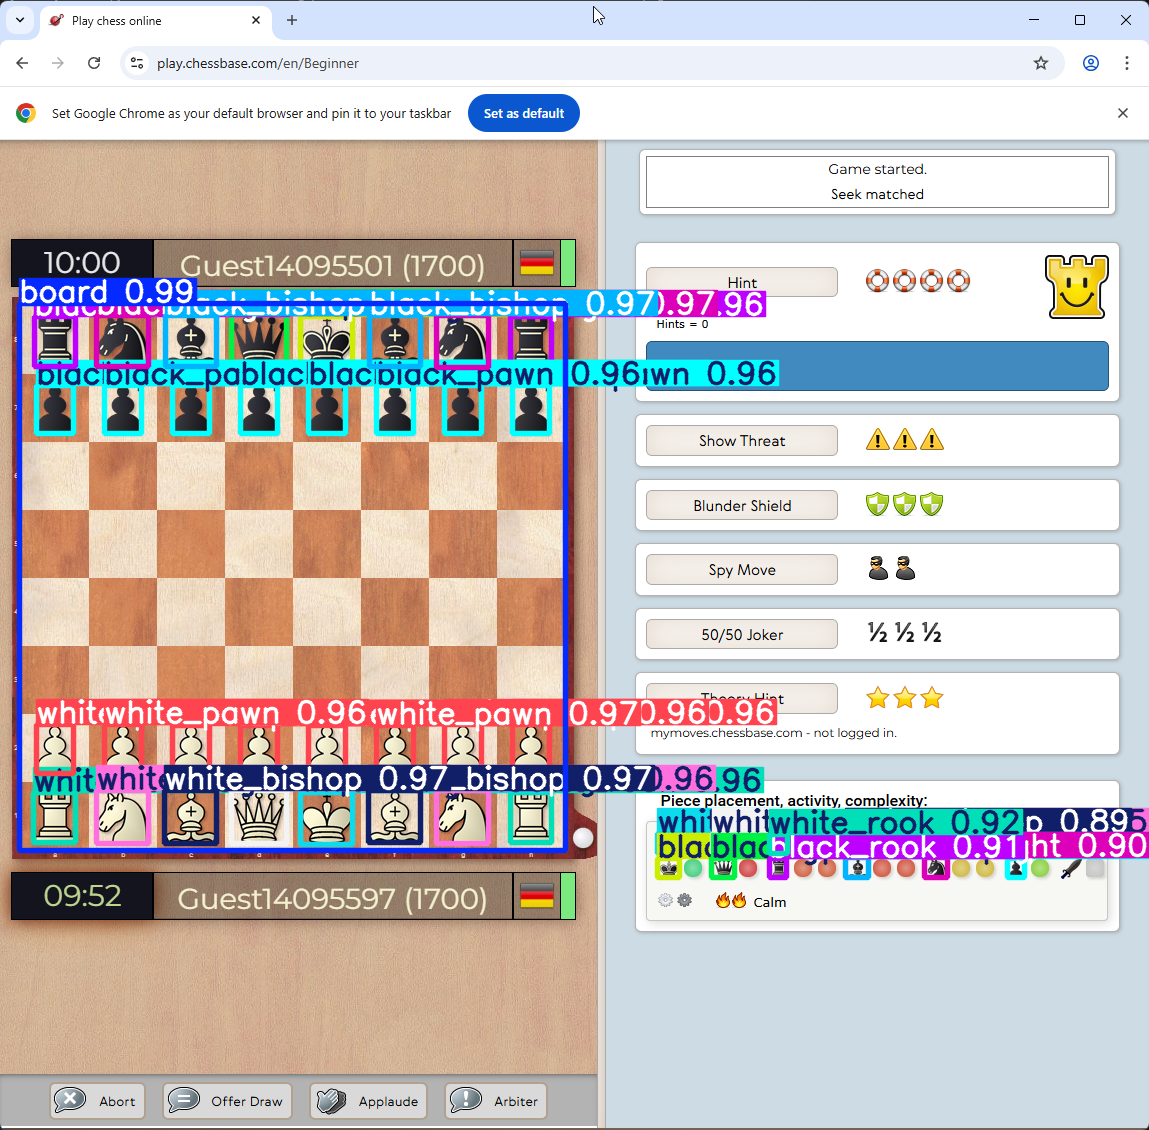

In [21]:
img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

In [20]:
import numpy as np

img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"
results = model.predict(img_path)
boxes = results[0].boxes
class_names = results[0].names

# Map class names to symbols
piece_symbols = {
    "white_king": "K", "white_queen": "Q", "white_rook": "R", "white_bishop": "B", "white_knight": "N", "white_pawn": "P",
    "black_king": "k", "black_queen": "q", "black_rook": "r", "black_bishop": "b", "black_knight": "n", "black_pawn": "p",
    "board": "."
}

# Find board bounding box
board_box = None
for box in boxes:
    cls_id = int(box.cls)
    if class_names[cls_id] == "board":
        board_box = box.xyxy[0].tolist()
        break

if board_box is None:
    print("No board detected.")
else:
    x1, y1, x2, y2 = board_box
    board_w = x2 - x1
    board_h = y2 - y1

    # Prepare empty board
    board = [["." for _ in range(8)] for _ in range(8)]

    # Place pieces
    for box in boxes:
        cls_id = int(box.cls)
        name = class_names[cls_id]
        if name == "board":
            continue
        # Get center of bounding box
        bx1, by1, bx2, by2 = box.xyxy[0].tolist()
        cx = (bx1 + bx2) / 2
        cy = (by1 + by2) / 2
        # Map to board square
        col = int(8 * (cx - x1) / board_w)
        row = int(8 * (cy - y1) / board_h)
        # Clamp to board
        col = min(max(col, 0), 7)
        row = min(max(row, 0), 7)
        # Place symbol
        board[row][col] = piece_symbols.get(name, "?")

    # Print board (top row first)
    for row in board:
        print(" ".join(row))

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N K
